# Calculate mAP scores for bulk profiles of only failing cells comparing the compounds at an MOA level to the control (DMSO)

In [1]:
import os
import pathlib

import numpy as np
import pandas as pd
from copairs import map  # noqa: A004
from copairs.matching import assign_reference_index
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_density,
    ggplot,
    labs,
    scale_color_manual,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from scipy.stats import mannwhitneyu, norm, wilcoxon
from tqdm import tqdm


## Helper functions

In [2]:
# Perform mean average precision calculation
def get_mean_average_precision(  # noqa: PLR0913
    activity_df: pd.DataFrame,
    pos_sameby: list,
    pos_diffby: list,
    neg_sameby: list,
    neg_diffby: list,
    seed: int = 0,
) -> pd.DataFrame:
    """Calculate mean average precision for activity data.

    Args:
        activity_df (pd.DataFrame): Activity data.
        pos_sameby (list): Positive samples to compare.
        pos_diffby (list): Positive samples to compare.
        neg_sameby (list): Negative samples to compare.
        neg_diffby (list): Negative samples to compare.
        seed (int, optional): Random seed for reproducibility. Defaults to 0.

    Returns:
        pd.DataFrame: Mean average precision results.
    """
    metadata = activity_df.filter(regex="^Metadata")
    profiles = activity_df.filter(regex="^(?!Metadata)").values

    activity_ap = map.average_precision(
        metadata, profiles, pos_sameby, pos_diffby, neg_sameby, neg_diffby
    )

    activity_map = map.mean_average_precision(
        activity_ap, pos_sameby, seed=seed, null_size=10000, threshold=0.05
    )
    activity_map["-log10(p-value)"] = -activity_map["corrected_p_value"].apply(np.log10)
    return activity_map


# Calculate proportion of points above, below, and equal to y=x per dose
def proportion_above_below_y_eq_x(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate the proportion of points above, below, and equal to the y=x line.

    Args:
        df (pd.DataFrame): DataFrame containing the activity data.

    Returns:
        pd.DataFrame: Dataframe with proportions and counts per dose.
    """
    results = []
    for dose, group in df.groupby("Metadata_dose_recode"):
        above = (
            group["mean_average_precision_postQC"]
            > group["mean_average_precision_preQC"]
        ).sum()
        below = (
            group["mean_average_precision_postQC"]
            < group["mean_average_precision_preQC"]
        ).sum()
        equal = (
            group["mean_average_precision_postQC"]
            == group["mean_average_precision_preQC"]
        ).sum()
        total = len(group)
        results.append(
            {
                "Metadata_dose_recode": dose,
                "proportion_above": above / total if total > 0 else np.nan,
                "proportion_below": below / total if total > 0 else np.nan,
                "proportion_equal": equal / total if total > 0 else np.nan,
                "n_points": total,
            }
        )
    return pd.DataFrame(results)


def calculate_replicate_cosine_similarity(
    activity_df: pd.DataFrame,
    group_cols: list[str] | None = None,
    exclude_profile_cols: list[str] | None = None,
    min_replicates: int = 2,
) -> pd.DataFrame:
    """Calculate pairwise replicate cosine similarity for all treatment groups.

    The returned rows are one compound-dose (or general group) each. The mean summarizes all
    pairwise cosine similarities among replicate profiles in that group.

    This function measures within-group reproducibility of feature profiles
    (e.g., compounds, doses, and DMSO controls) by computing cosine similarity
    between replicate feature vectors in a shared feature space.

    Args:
        activity_df (pd.DataFrame): DataFrame containing activity data with metadata and
            profile columns (feature space used for cosine similarity).
        group_cols (list[str], optional): List of metadata columns to group by. Defaults
            to ["Metadata_broad_sample", "Metadata_dose_recode"].
        exclude_profile_cols (list[str], optional): List of numeric columns to exclude
            from profile data (e.g., "failed_proportion").
            Defaults to ["failed_proportion"].
        min_replicates (int, optional): Minimum number of replicates required to
            calculate cosine similarity. Defaults to 2.

    Returns:
        pd.DataFrame: DataFrame with group columns and summary statistics of
            pairwise cosine similarity for each treatment group.
    """
    # Set default columns if not provided
    if group_cols is None:
        group_cols = ["Metadata_broad_sample", "Metadata_dose_recode"]
    if exclude_profile_cols is None:
        exclude_profile_cols = ["failed_proportion"]

    # Use full dataset (no external filtering / map restriction)
    activity_subset = activity_df.copy()

    # Identify profile columns by excluding metadata and specified columns
    metadata_cols = activity_subset.filter(regex="^Metadata").columns
    numeric_cols = activity_subset.select_dtypes(include="number").columns
    profile_cols = [
        col
        for col in numeric_cols
        if col not in metadata_cols and col not in exclude_profile_cols
    ]

    # Calculate pairwise cosine similarity for each group and store results
    results = []
    for group_values, group_df in activity_subset.groupby(group_cols, dropna=False):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        # Extract profile data and handle NaN values by replacing them with zeros
        profiles = group_df[profile_cols].to_numpy(dtype=float)
        profiles = np.nan_to_num(profiles, nan=0.0, posinf=0.0, neginf=0.0)

        # Skip groups with fewer than the minimum number of replicates
        if profiles.shape[0] < min_replicates:
            continue

        # Ensure proper cosine similarity even if upstream normalization drifted
        norms = np.linalg.norm(profiles, axis=1, keepdims=True)
        profiles = np.divide(
            profiles, norms, out=np.zeros_like(profiles), where=norms != 0
        )

        cosine_matrix = profiles @ profiles.T

        # Extract upper triangle (excluding diagonal)
        pair_indices = np.triu_indices(profiles.shape[0], k=1)
        pairwise_cosine = cosine_matrix[pair_indices]

        # Store results with group values and summary statistics
        results.append(
            {
                **dict(zip(group_cols, group_values, strict=True)),
                "n_replicates": profiles.shape[0],
                "n_pairwise_comparisons": pairwise_cosine.size,
                "mean_pairwise_cosine_similarity": pairwise_cosine.mean(),
                "median_pairwise_cosine_similarity": np.median(pairwise_cosine),
                "std_pairwise_cosine_similarity": (
                    pairwise_cosine.std(ddof=1) if pairwise_cosine.size > 1 else 0.0
                ),
            }
        )

    return pd.DataFrame(results)


## Load in the data for post QC and only failing QC cells

In [3]:
MIN_REPLICATES = 2

input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

output_dir = pathlib.Path("./mAP_results")
output_dir.mkdir(parents=True, exist_ok=True)

post_qc_file = pathlib.Path(
    input_dir,
    "whole_batch_post_qc_cpd_replicates.parquet",
)
post_qc_df = pd.read_parquet(post_qc_file)
post_qc_df = post_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
post_qc_df["Metadata_sc_count_failed_qc"] = post_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

failing_qc_file = pathlib.Path(
    input_dir,
    "whole_batch_post_qc_cpd_replicates_only_failing_cells.parquet",
)
failing_qc_df = pd.read_parquet(failing_qc_file)
failing_qc_df = failing_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
failing_qc_df["Metadata_sc_count_failed_qc"] = failing_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

failing_qc_df.loc[
    failing_qc_df["Metadata_broad_sample"] == "DMSO",
    "Metadata_broad_sample",
] = "DMSO_failing"

post_dmso_df = post_qc_df[post_qc_df["Metadata_broad_sample"] == "DMSO"].copy()

meta_cols = [c for c in post_dmso_df.columns if c.startswith("Metadata_")]

post_features = set(post_dmso_df.columns) - set(meta_cols)
failing_features = set(failing_qc_df.columns) - set(meta_cols)

shared_features = list(post_features & failing_features)
shared_meta = list(
    set(meta_cols) & set(failing_qc_df.columns) & set(post_dmso_df.columns)
)

post_dmso_df = pd.concat(
    [post_dmso_df[shared_meta], post_dmso_df[shared_features]],
    axis=1,
)

failing_qc_df = pd.concat(
    [failing_qc_df[shared_meta], failing_qc_df[shared_features]],
    axis=1,
)

map_df = pd.concat(
    [post_dmso_df, failing_qc_df],
    ignore_index=True,
)

print(f"Post-QC DMSO profiles: {len(post_dmso_df):,}")
print(f"Failing-cell profiles: {len(failing_qc_df):,}")
print(f"Combined profiles: {len(map_df):,}")


Post-QC DMSO profiles: 3,264
Failing-cell profiles: 51,828
Combined profiles: 55,092


In [4]:
print(map_df.shape)
map_df.head()


(55092, 802)


,Metadata_pert_id,Metadata_broad_sample,Metadata_sc_count,Metadata_Well,Metadata_dose_recode,Metadata_sc_count_passed_qc,Metadata_broad_id,Metadata_moa,Metadata_Plate,Metadata_sc_count_failed_qc,...,Nuclei_Granularity_3_Mito,Cytoplasm_AreaShape_Zernike_9_7,Nuclei_Granularity_2_ER,Cytoplasm_RadialDistribution_MeanFrac_ER_3of4,Cells_AreaShape_Zernike_7_5,Cells_Texture_Correlation_AGP_10_0,Nuclei_Texture_DifferenceEntropy_RNA_20_0,Nuclei_RadialDistribution_RadialCV_RNA_2of4,Cells_RadialDistribution_FracAtD_Mito_3of4,Cells_AreaShape_Eccentricity
0,None,DMSO,2050,A01,0,1205.0,None,None,SQ00014812,845.0,...,-0.673290,-0.980499,1.428114,-0.601815,-0.118883,0.055815,-2.058321,0.091668,-1.011468,1.500461
1,None,DMSO,2276,A02,0,1610.0,None,None,SQ00014812,666.0,...,0.562666,0.027853,0.836463,-1.149160,-0.100626,0.236007,-2.640255,0.725405,-1.478381,0.930128
2,None,DMSO,2634,A03,0,1811.0,None,None,SQ00014812,823.0,...,0.081518,-0.425949,0.849552,-0.448151,-0.797645,-0.048691,-1.553512,-0.288267,0.721310,-0.423261
3,None,DMSO,2807,A04,0,1993.0,None,None,SQ00014812,814.0,...,-0.101809,-0.460549,0.127692,0.472539,-0.777039,-0.389902,-1.731419,0.069878,-1.401957,0.297617
4,None,DMSO,2928,A05,0,2372.0,None,None,SQ00014812,556.0,...,-0.704273,0.228395,0.490503,1.021903,-0.035236,-0.118582,-0.765227,0.289411,-0.189366,-0.887950


## Assign reference index

In [5]:
reference_col = "Metadata_reference_index"

map_df_activity = assign_reference_index(
    map_df,
    "Metadata_broad_sample == 'DMSO'",  # ONLY post-QC DMSO matches this now
    reference_col=reference_col,
    default_value=-1,
)


## Set positive and negative pairs for compounds

In [6]:
# positive pairs are replicates of the same treatment
pos_sameby = ["Metadata_broad_sample", "Metadata_dose_recode", reference_col]
pos_diffby = ["Metadata_Plate"]

# negative pairs are replicates of different treatments
neg_sameby = []  # set plate if you don't want to compare controls across all plates
neg_diffby = ["Metadata_broad_sample", reference_col]


## Calculate mAP scores for failing cells per treatment compared to post-QC controls

In [7]:
postqc_map_file = f"{output_dir}/final_map_scores_failing_vs_postQC_controls.parquet"

if os.path.exists(postqc_map_file):
    final_map_postQC = pd.read_parquet(postqc_map_file)
    print("Loaded failing-vs-postQC mAP results from file.")

else:
    list_of_dfs_map_postQC = []

    # Isolate post-QC DMSO reference pool from unified dataframe
    postqc_dmso = map_df_activity[
        map_df_activity["Metadata_broad_sample"] == "DMSO"
    ].copy()

    # Loop over failing-cell compounds only
    failing_treatments = (
        map_df_activity.loc[
            map_df_activity["Metadata_broad_sample"].str.contains("DMSO") == False,
            "Metadata_broad_sample",
        ].unique()
    )

    for treatment in failing_treatments:

        if treatment in ["DMSO", "DMSO_failing"]:
            continue

        # Failing treatment subset from unified dataframe
        treatment_df = map_df_activity[
            map_df_activity["Metadata_broad_sample"] == treatment
        ].copy()

        # Attach ONLY post-QC DMSO controls
        treatment_df = pd.concat(
            [treatment_df, postqc_dmso],
            ignore_index=True
        )

        treatment_plates = treatment_df["Metadata_Plate"].unique()

        treatment_df = treatment_df[
            treatment_df["Metadata_Plate"].isin(treatment_plates)
        ]

        # replicate check (failing only)
        n_replicates = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ].shape[0]

        unique_pos_diffby = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ][pos_diffby].drop_duplicates()

        if n_replicates < MIN_REPLICATES or unique_pos_diffby.shape[0] < MIN_REPLICATES:
            print(
                f"Skipping treatment {treatment}: not enough failing replicates or "
                f"not enough unique '{pos_diffby}' values for positive pairs."
            )
            continue

        # FIX 5: failed-cell proportion (only failing subset)
        failed_cells = (
            treatment_df[
                treatment_df["Metadata_broad_sample"] == treatment
            ]
            .assign(
                Metadata_failed_prop=lambda x: (
                    x["Metadata_sc_count_failed_qc"] / x["Metadata_sc_count"]
                )
            )
            .groupby("Metadata_dose_recode")["Metadata_failed_prop"]
            .mean()
        )

        # mAP calculation on unified space (post-QC DMSO + failing compounds)
        treatment_map = get_mean_average_precision(
            treatment_df,
            pos_sameby,
            pos_diffby,
            neg_sameby,
            neg_diffby
        )

        # attach QC metric
        treatment_map["Metadata_avg_prop_failed_single_cells"] = (
            treatment_map["Metadata_dose_recode"].map(failed_cells)
        )

        list_of_dfs_map_postQC.append(treatment_map)

    # concatenate results
    final_map_postQC = pd.concat(list_of_dfs_map_postQC, ignore_index=True)
    final_map_postQC["QC_status"] = "failing_vs_postQC_controls"

    # save
    final_map_postQC.to_parquet(postqc_map_file, index=False)


Loaded failing-vs-postQC mAP results from file.


In [8]:
final_map_postQC.head()


,Metadata_broad_sample,Metadata_dose_recode,Metadata_reference_index,mean_average_precision,indices,mean_normalized_average_precision,p_value,corrected_p_value,below_p,below_corrected_p,-log10(p-value),Metadata_avg_prop_failed_single_cells,QC_status
0,BRD-A00147595-001-01-5,1,-1,0.400572,"[5, 11, 17, 23]",0.398608,0.0001,0.00012,True,True,3.920862,0.246434,failing_vs_postQC_controls
1,BRD-A00147595-001-01-5,2,-1,0.500383,"[4, 10, 16, 22]",0.498747,0.0001,0.00012,True,True,3.920862,0.283612,failing_vs_postQC_controls
2,BRD-A00147595-001-01-5,3,-1,0.278338,"[3, 9, 15, 21]",0.275975,0.0011,0.00110,True,True,2.958651,0.284254,failing_vs_postQC_controls
3,BRD-A00147595-001-01-5,4,-1,0.500437,"[2, 8, 14, 20]",0.498801,0.0001,0.00012,True,True,3.920862,0.272083,failing_vs_postQC_controls
4,BRD-A00147595-001-01-5,5,-1,0.824692,"[1, 7, 13, 19]",0.824117,0.0001,0.00012,True,True,3.920862,0.259502,failing_vs_postQC_controls


In [9]:
# Load in mAP scores only passing cells
pre_QC_map = pd.read_parquet("../figure_5/mAP_results/final_map_scores_preQC.parquet")
passing_post_QC_map = pd.read_parquet(
    "../figure_5/mAP_results/final_map_scores_postQC.parquet"
)

# Merge preQC and postQC results on sample and dose
merged_map = pd.merge(
    pre_QC_map,
    passing_post_QC_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_preQC", "_postQC"),
)

# Compute change per row
merged_map["mAP_change"] = (
    merged_map["mean_average_precision_postQC"]
    - merged_map["mean_average_precision_preQC"]
)

# Label direction of change
merged_map["mAP_trend"] = np.select(
    [
        merged_map["mAP_change"] > 0,
        merged_map["mAP_change"] < 0,
    ],
    [
        "increase",
        "decrease",
    ],
    default="no_change",
)

# Keep only trend mapping
trend_map = merged_map[["Metadata_broad_sample", "Metadata_dose_recode", "mAP_trend"]]

# Merge into final post-QC dataframe
final_map_postQC_trend = final_map_postQC.merge(
    trend_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)


QC_state            mAP_trend
Only failing cells  Decreased    4849
                    Increased    3424
Only passing cells  Decreased    4849
                    Increased    3424
Name: count, dtype: int64


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8.5 x 5 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./figures/only_failing_vs_passing_mAP_scores_dist_by_trend.png


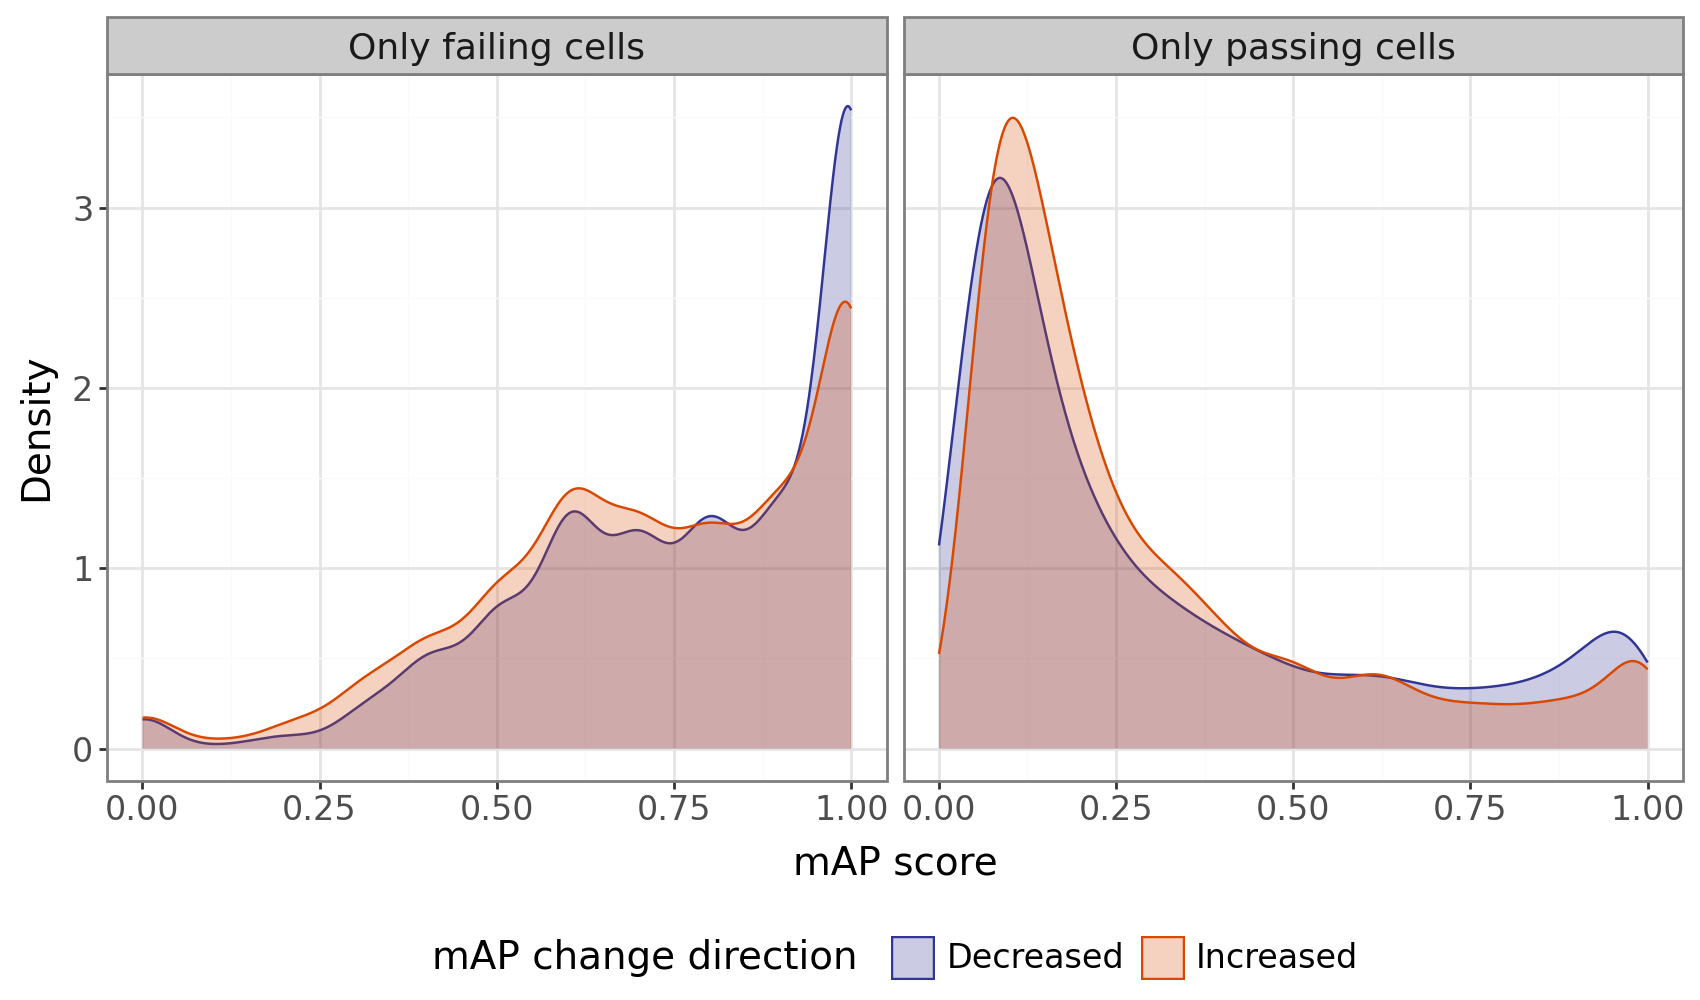

In [10]:
# -----------------------------
# 1. Merge trend_map into BOTH QC datasets (failing_QC already has it, but redo for consistency)
# -----------------------------
final_map_postQC_trend_labeled = final_map_postQC.merge(
    trend_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)
post_qc_labeled = passing_post_QC_map.merge(
    trend_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)

# -----------------------------
# 2. Drop rows with no change or missing trend
# -----------------------------
final_map_postQC_trend_labeled = final_map_postQC_trend_labeled[
    final_map_postQC_trend_labeled["mAP_trend"].isin(["increase", "decrease"])
]
post_qc_labeled = post_qc_labeled[
    post_qc_labeled["mAP_trend"].isin(["increase", "decrease"])
]

# -----------------------------
# 3. Add QC labels
# -----------------------------
final_map_postQC_trend_labeled["QC_state"] = "failed_QC_cells"
post_qc_labeled["QC_state"] = "passed_QC_cells"

# -----------------------------
# 4. Combine
# -----------------------------
plot_df = pd.concat(
    [final_map_postQC_trend_labeled, post_qc_labeled], ignore_index=True
)

# -----------------------------
# 5. Standardize labels for plotting
# -----------------------------
plot_df["QC_state"] = plot_df["QC_state"].replace(
    {
        "failed_QC_cells": "Only failing cells",
        "passed_QC_cells": "Only passing cells",
    }
)
plot_df["mAP_trend"] = plot_df["mAP_trend"].replace(
    {"increase": "Increased", "decrease": "Decreased"}
)

# Diagnostic — confirm both trends are present in each QC state
print(plot_df.groupby("QC_state")["mAP_trend"].value_counts(dropna=False))

# -----------------------------
# 6. Density plot (KDE curves), faceted by QC state, colored by trend
# -----------------------------
p = (
    ggplot(
        plot_df,
        aes(
            x="mean_average_precision",
            color="mAP_trend",
            fill="mAP_trend",
        ),
    )
    + geom_density(alpha=0.25)
    + facet_wrap("~QC_state")
    + scale_color_manual(values={"Decreased": "#313695", "Increased": "#d94801"})
    + scale_fill_manual(values={"Decreased": "#313695", "Increased": "#d94801"})
    + theme_bw()
    + theme(
        figure_size=(8.5, 5),
        axis_title=element_text(size=14),
        axis_text=element_text(size=12),
        legend_title=element_text(size=14),
        legend_text=element_text(size=12),
        strip_text=element_text(size=13),
        legend_position="bottom",
    )
    + labs(
        x="mAP score",
        y="Density",
        color="mAP change direction",
        fill="mAP change direction",
    )
)
p.save("./figures/only_failing_vs_passing_mAP_scores_dist_by_trend.png", dpi=600)
p.show()


In [11]:
# Build an explicit paired table: one row per compound+dose condition, with
# both the "only failing cells" and "only passing cells" mAP scores as
# separate columns. `failed` and `passed` below come straight out of this
# merge (rather than being independently re-filtered from `plot_df`), so
# `failed[i]` and `passed[i]` are guaranteed to refer to the same
# compound+dose -- this matters once we treat the two mAP scores as a
# matched pair rather than two unrelated samples (see the next cell).
paired_map = final_map_postQC_trend_labeled.merge(
    post_qc_labeled,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_failed", "_passed"),
)

failed = paired_map["mean_average_precision_failed"]
passed = paired_map["mean_average_precision_passed"]

print(f"n paired compound+dose conditions: {len(paired_map)}")
print(f"median: failed={failed.median():.4f}, passed={passed.median():.4f}")
print(f"mean:   failed={failed.mean():.4f}, passed={passed.mean():.4f}")


n paired compound+dose conditions: 8273
median: failed=0.8004, passed=0.1853
mean:   failed=0.7545, passed=0.3046


In [12]:
# `failed cells` and `passed cells` are two mAP scores computed for the SAME
# compound+dose condition. Only the cells feeding the aggregate profile differ, but the
# compound+dose identity (and any shared, condition-level signal) is
# identical across the pair. That makes this a matched-pairs design, not two
# independent samples: a rank-sum test (Mann-Whitney U) ignores the pairing
# and is not the appropriate primary test here. The matched-pairs analogue is
# the Wilcoxon signed-rank test on the per-condition differences
# (failed cells - passed cells).
#
# At n ~ 8e3 pairs, the p-value underflows double precision and prints as
# exactly 0.0 either way, which is never literally true for a continuous test
# statistic. We recompute it in log-space from the normal approximation so
# we can report an actual (if extreme) order of magnitude instead of "p = 0".
# The variance term includes scipy's tie correction (sum(t_i**3 - t_i) over
# groups of tied |diff| values) so the z/p-value matches what
# scipy.stats.wilcoxon computes internally when differences repeat; with no
# ties this reduces exactly to the untied n(n+1)(2n+1)/24 formula.
stat, p = wilcoxon(failed, passed, alternative="greater", zero_method="wilcox")

diff = (failed - passed).to_numpy()
diff_nz = diff[diff != 0]
n = len(diff_nz)
abs_diff = np.abs(diff_nz)
ranks = pd.Series(abs_diff).rank()  # average ranks for ties, matches scipy's approach

# Sum of signed ranks (positive differences)
T = ranks[diff_nz > 0].sum()

mean_T = n * (n + 1) / 4

# Tie correction: group tied |diff| values and compute sum(t_i^3 - t_i)
_, counts = np.unique(abs_diff, return_counts=True)
tie_correction = np.sum(counts**3 - counts)

var_T = (n * (n + 1) * (2 * n + 1) - tie_correction / 2) / 24
se_T = np.sqrt(var_T)

z = (T - mean_T) / se_T
log10_p = norm.logsf(z) / np.log(10)  # for alternative="greater"

print(f"Wilcoxon signed-rank statistic = {stat:.0f}")
print(f"n pairs (nonzero differences) = {n}")
print(f"z = {z:.2f}")
print(f"p-value (scipy, underflows past ~1e-308): {p:.3e}")
print(f"p-value (normal approximation, log-space): < 1e{np.ceil(log10_p):.0f}")


Wilcoxon signed-rank statistic = 33420378
n pairs (nonzero differences) = 8207
z = 77.24
p-value (scipy, underflows past ~1e-308): 0.000e+00
p-value (normal approximation, log-space): < 1e-1297


In [13]:
def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    """
    Calculate Cliff's delta, a non-parametric effect size
    measure for two independent samples.

    Args:
        x (np.ndarray): First sample.
        y (np.ndarray): Second sample.

    Returns:
        float: Cliff's delta value, ranging from -1 to 1.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    gt = np.sum(x[:, None] > y)
    lt = np.sum(x[:, None] < y)

    return (gt - lt) / (len(x) * len(y))


# Cliff's delta treats `failed` and `passed` as independent samples -- kept
# here for comparability with the original (unpaired) framing.
delta = cliffs_delta(failed, passed)
print(f"Cliff's delta (unpaired framing) = {delta:.3f}")

# Matched-pairs rank-biserial correlation, the effect-size analogue of the
# Wilcoxon signed-rank test above. Computed from the signed-rank sums:
# W+ (already computed as T in the previous cell) and W- (sum of ranks for
# negative differences).
w_plus = T
w_minus = ranks[diff_nz < 0].sum()
rank_biserial = (w_plus - w_minus) / (w_plus + w_minus)
print(f"Matched rank-biserial correlation (paired framing) = {rank_biserial:.4f}")


Cliff's delta (unpaired framing) = 0.744
Matched rank-biserial correlation (paired framing) = 0.9845
